# Descriptive Analysis of Automobile Insurance Fraud Data


Run the notebook from top to bottom.


## 1. Data Source

Clone or download the project repository from GitHub. Then place the following authorised data files in the project's `data` folder:

- `train_model_dataset.parquet`
- `test_model_dataset.parquet`

In the next code cell, update `PROJECT_FOLDER` to the location of the downloaded project folder on your computer. The variable descriptions are loaded automatically from the repository.

In [3]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Run Jupyter from the cloned repository root.
PROJECT_FOLDER = Path.cwd().resolve()
if not (PROJECT_FOLDER / "data").exists():
    raise FileNotFoundError(
        "Start Jupyter from the repository root so the data folder can be found."
    )

DATA_FOLDER = PROJECT_FOLDER / "data"
TARGET = "respuesta_dicot_c"
YEAR_DAYS = 365.25

train_path = DATA_FOLDER / "train_model_dataset.parquet"
test_path = DATA_FOLDER / "test_model_dataset.parquet"
audit_path = (
    PROJECT_FOLDER
    / "outputs"
    / "leakage_analysis"
    / "leakage_audit.csv"
)

required_files = [train_path, test_path, audit_path]
missing_files = [path for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following files were not found:\n"
        + "\n".join(str(path) for path in missing_files)
        + "\n\nCheck PROJECT_FOLDER and confirm that the two "
          "Parquet files are stored in the data folder."
    )

# Load the training data.
train = pd.read_parquet(train_path)

if TARGET not in train.columns:
    raise ValueError(f"Target column not found: {TARGET}")

features = [
    column for column in train.columns
    if column != TARGET
]

# Load test features only. The test target is not loaded.
test_features = pd.read_parquet(
    test_path,
    columns=features
)

# Load the approved English variable descriptions.
audit = pd.read_csv(audit_path)
descriptions = dict(
    zip(audit["variable"], audit["description"])
)

# Confirm that known leakage variables are excluded.
confirmed_exclusions = {
    "respuesta_dicot1",
    "situacionvts",
    "scoreada",
}

if confirmed_exclusions.intersection(features):
    raise ValueError(
        "A confirmed leakage feature is present in the modelling files."
    )

assert set(train[TARGET].unique()).issubset({0, 1})
assert list(test_features.columns) == features

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 90)

print(f"Project folder: {PROJECT_FOLDER}")
print(f"Training data: {train_path}")
print(f"Test features: {test_path}")
print(f"Variable descriptions: {audit_path}")
print(f"Loaded training shape: {train.shape}")
print(f"Loaded test-feature shape: {test_features.shape}")
print("Test target loaded: No")

Project folder: <PROJECT_ROOT>
Training data: <PROJECT_ROOT>\data\train_model_dataset.parquet
Test features: <PROJECT_ROOT>\data\test_model_dataset.parquet
Variable descriptions: <PROJECT_ROOT>\outputs\leakage_analysis\leakage_audit.csv
Loaded training shape: (444074, 145)
Loaded test-feature shape: (111020, 144)
Test target loaded: No


## 2. Variable Names and Units

English names are used in the narrative and figures. Tables also retain the original Spanish variable names for traceability. Technical external-data codes such as `ine_008` are retained and paired with their English descriptions. Original category labels are not translated because they may have company-specific meanings.

The variable dictionary describes `antiguedad_poliza` and `dias_notificacion` as days. However, every supplied value becomes a whole number of days when multiplied by 365.25, showing that both columns are stored as fractions of a year. Policy tenure is presented in years; notification delay is converted back to days for readability. The modelling values are not changed.


In [4]:
# ---------------------------------------------------------------------
# 2. Statistical types and display conventions
# ---------------------------------------------------------------------

CODE_FEATURES = {
    "comarcaid",
    "tomadorcodigopostal",
    "tomadormunicipioid",
    "tomadorprovinciaid",
    "tomadorcomarcaid",
    "tomadornacionalidadid",
}

BINARY_FEATURES = {
    "flota",
    "aceptoculpasinantecedentes",
    "contratalunas",
    "contrataasistencia",
    "contratadanyospropios",
    "dias_notificacion2",
}

COUNT_FEATURES = {"actasvariacion", "puertas"}

DISPLAY_NAMES = {
    "edad_conductor1": "Driver age",
    "antiguedad_poliza": "Policy tenure",
    "dias_notificacion": "Notification delay",
    "actasvariacion": "Previous claims count",
    "anyomatricula": "Vehicle registration year",
    "valorvehiculomercado": "Vehicle market value",
    "valorvehiculofabrica": "Insured vehicle value",
    "potencia": "Engine power",
    "cilindrada": "Engine displacement",
    "pesovehiculo": "Vehicle weight",
    "pesomaxautorizado": "Maximum authorised weight",
    "longitud": "Vehicle length",
    "puertas": "Number of doors",
    "garantia_agrupada": "Grouped coverage",
    "scoring": "Risk scoring group",
    "canalnombre": "Sales channel",
    "formapago_agrupado": "Grouped payment method",
    "sexo": "Sex",
    "flota": "Fleet indicator",
}


def english_name(variable):
    return DISPLAY_NAMES.get(variable, descriptions.get(variable, variable))


def analysis_type(variable):
    series = train[variable]
    if variable in CODE_FEATURES:
        return "categorical code"
    if variable in BINARY_FEATURES:
        return "binary"
    if variable in COUNT_FEATURES:
        return "count"
    if not pd.api.types.is_numeric_dtype(series):
        return "categorical"
    return "continuous"


def displayed_values(frame, variable):
    values = pd.to_numeric(frame[variable], errors="coerce")
    if variable == "dias_notificacion":
        return values * YEAR_DAYS
    return values


def displayed_unit(variable):
    return {
        "anyomatricula": "year",
        "valorvehiculomercado": "currency units",
        "valorvehiculofabrica": "currency units",
        "potencia": "hp",
        "cilindrada": "cc",
        "pesovehiculo": "kg",
        "pesomaxautorizado": "kg",
        "longitud": "mm",
        "edad_conductor1": "years",
        "antiguedad_poliza": "years",
        "dias_notificacion": "days",
    }.get(variable, "")


feature_types = pd.DataFrame(
    {
        "variable": features,
        "english_name": [english_name(variable) for variable in features],
        "original_variable": features,
        "description": [descriptions.get(variable, "") for variable in features],
        "storage_dtype": [str(train[variable].dtype) for variable in features],
        "analysis_type": [analysis_type(variable) for variable in features],
        "display_unit": [displayed_unit(variable) for variable in features],
        "unique_values": [
            train[variable].nunique(dropna=False) for variable in features
        ],
    }
)

numeric_features = feature_types.loc[
    feature_types["analysis_type"].isin(["continuous", "count"]), "variable"
].tolist()
categorical_features = feature_types.loc[
    feature_types["analysis_type"].isin(
        ["categorical", "categorical code", "binary"]
    ),
    "variable",
].tolist()

## 3. Dataset Summary

Summarise sample size, feature counts, missingness, duplicates, and the severe class imbalance.


,Metric,Result
0,Training observations,"444,074"
1,Approved features,144
2,Numeric/count features,114
3,Categorical/code/binary features,30
4,Missing cells,0
5,Duplicate full rows,"3,503"
6,Fraud observations,"1,860"
7,Fraud prevalence,0.4188%
8,Non-fraud to fraud ratio,237.7:1


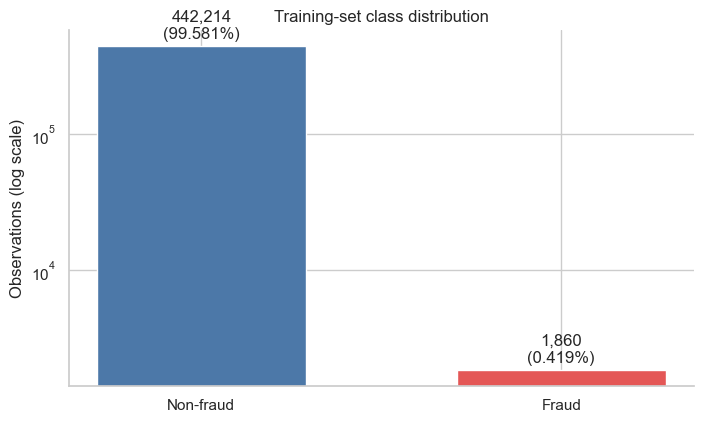

In [5]:
# ---------------------------------------------------------------------
# 3. Dataset overview
# ---------------------------------------------------------------------

def styled_table(frame, percent_columns=(), decimal_columns=(), integer_columns=()):
    formatters = {}
    formatters.update({column: "{:,.3f}".format for column in decimal_columns})
    formatters.update({column: "{:,.3f}%".format for column in percent_columns})
    formatters.update({column: "{:,.0f}".format for column in integer_columns})
    try:
        return frame.style.format(formatters).hide(axis="index")
    except AttributeError:
        formatted = frame.copy()
        for column, formatter in formatters.items():
            formatted[column] = formatted[column].map(formatter)
        return formatted


fraud_count = int(train[TARGET].sum())
nonfraud_count = int((train[TARGET] == 0).sum())
fraud_rate = float(train[TARGET].mean() * 100)

overview = pd.DataFrame(
    {
        "Metric": [
            "Training observations",
            "Approved features",
            "Numeric/count features",
            "Categorical/code/binary features",
            "Missing cells",
            "Duplicate full rows",
            "Fraud observations",
            "Fraud prevalence",
            "Non-fraud to fraud ratio",
        ],
        "Result": [
            f"{len(train):,}",
            f"{len(features):,}",
            f"{len(numeric_features):,}",
            f"{len(categorical_features):,}",
            f"{int(train.isna().sum().sum()):,}",
            f"{int(train.duplicated(keep=False).sum()):,}",
            f"{fraud_count:,}",
            f"{fraud_rate:.4f}%",
            f"{nonfraud_count / fraud_count:.1f}:1",
        ],
    }
)

display(styled_table(overview))

fig, ax = plt.subplots(figsize=(7.2, 4.4))
counts = train[TARGET].value_counts().reindex([0, 1], fill_value=0)
bars = ax.bar(
    ["Non-fraud", "Fraud"],
    counts.values,
    color=["#4C78A8", "#E45756"],
    width=0.58,
)
ax.set_yscale("log")
ax.set_ylabel("Observations (log scale)")
ax.set_title("Training-set class distribution")
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.08,
        f"{count:,}\n({count / counts.sum() * 100:.3f}%)",
        ha="center",
        va="bottom",
    )
sns.despine()
plt.tight_layout()
plt.show()

# See the specific interpretation below.

The training set contains **444,074 observations**, including **1,860 fraud cases (0.4188%)**. This is approximately **238 non-fraud cases for every fraud case**. There are no missing cells. **3,503 rows participate in duplicate full records**, but these duplicates remain within the training partition and do not overlap the test set.


## 4. Data Quality

Flag questionable ranges and representations without automatically deleting or correcting observations.


In [6]:
# ---------------------------------------------------------------------
# 4. Data quality
# ---------------------------------------------------------------------

def quality_row(variable, check, mask):
    return {
        "Variable": variable,
        "Review item": check,
        "Records": int(mask.sum()),
        "Share (%)": float(mask.mean() * 100),
    }


quality_checks = [
    quality_row(
        "antiguedad_poliza",
        "Negative policy tenure",
        train["antiguedad_poliza"].lt(0),
    ),
    quality_row(
        "dias_notificacion",
        "Notification delay longer than 365 days",
        train["dias_notificacion"].mul(YEAR_DAYS).gt(365),
    ),
    quality_row(
        "anyomatricula",
        "Registration year outside 1900-2026",
        ~train["anyomatricula"].between(1900, 2026),
    ),
    quality_row(
        "edad_conductor1",
        "Driver age outside 16-100 years",
        ~train["edad_conductor1"].between(16, 100),
    ),
    quality_row(
        "puertas",
        "Number of doors outside 1-6",
        ~train["puertas"].between(1, 6),
    ),
    quality_row(
        "puertas",
        "Non-integer number of doors",
        (train["puertas"] - train["puertas"].round()).abs().gt(1e-8),
    ),
]

for variable in [
    "valorvehiculomercado",
    "valorvehiculofabrica",
    "potencia",
    "cilindrada",
    "pesovehiculo",
    "pesomaxautorizado",
]:
    quality_checks.append(
        quality_row(
            variable,
            "Zero or negative value; review as a possible not-applicable code",
            train[variable].le(0),
        )
    )

quality = (
    pd.DataFrame(quality_checks)
    .query("Records > 0")
    .sort_values("Records", ascending=False)
)

display(
    styled_table(
        quality,
        percent_columns=["Share (%)"],
        integer_columns=["Records"],
    )
)
# See the specific interpretation below.

,Variable,Review item,Records,Share (%)
11,pesomaxautorizado,Zero or negative value; review as a possible not-applicable code,"325,853",73.378%
5,puertas,Non-integer number of doors,"42,858",9.651%
7,valorvehiculofabrica,Zero or negative value; review as a possible not-applicable code,"32,370",7.289%
6,valorvehiculomercado,Zero or negative value; review as a possible not-applicable code,"1,875",0.422%
3,edad_conductor1,Driver age outside 16-100 years,792,0.178%
10,pesovehiculo,Zero or negative value; review as a possible not-applicable code,650,0.146%
9,cilindrada,Zero or negative value; review as a possible not-applicable code,342,0.077%
1,dias_notificacion,Notification delay longer than 365 days,331,0.075%
4,puertas,Number of doors outside 1-6,77,0.017%
8,potencia,Zero or negative value; review as a possible not-applicable code,24,0.005%


The main review items are **325,853 zero maximum-authorised-weight values (73.38%)**, **42,858 non-integer door counts (9.65%)**, and **32,370 zero insured-vehicle values (7.29%)**. These large groups may be structural "not applicable" codes. In addition, **331 notification delays exceed one year**, **10 registration years fall outside 1900-2026**, and **6 policy-tenure values are negative**. The lowest policy tenure equals **-37 days** after conversion.


## 5. Numeric Variables

Calculate concise summaries and fraud/non-fraud effect sizes for genuine numeric variables.


In [7]:
# ---------------------------------------------------------------------
# 5. Numeric descriptions and class comparisons
# ---------------------------------------------------------------------

numeric_rows = []
comparison_rows = []
target = train[TARGET].astype(int)

for variable in numeric_features:
    values = displayed_values(train, variable)
    q1, median, q3 = values.quantile([0.25, 0.5, 0.75])
    numeric_rows.append(
        {
            "variable": variable,
            "english_name": english_name(variable),
            "description": descriptions.get(variable, ""),
            "unit": displayed_unit(variable),
            "mean": values.mean(),
            "median": median,
            "q1": q1,
            "q3": q3,
            "minimum": values.min(),
            "maximum": values.max(),
            "skewness": values.skew(),
        }
    )

    nonfraud = values[target.eq(0)]
    fraud = values[target.eq(1)]
    pooled_variance = (
        (len(nonfraud) - 1) * nonfraud.var()
        + (len(fraud) - 1) * fraud.var()
    ) / (len(nonfraud) + len(fraud) - 2)
    pooled_sd = math.sqrt(max(float(pooled_variance), 0))
    standardized_difference = (
        (fraud.mean() - nonfraud.mean()) / pooled_sd if pooled_sd > 0 else 0
    )
    comparison_rows.append(
        {
            "English name": english_name(variable),
            "Original variable": variable,
            "Direction": (
                "Higher in fraud"
                if standardized_difference > 0
                else "Lower in fraud"
            ),
            "Std. difference": standardized_difference,
            "Correlation": values.corr(target),
        }
    )

numeric_summary = pd.DataFrame(numeric_rows)
numeric_comparison = pd.DataFrame(comparison_rows).assign(
    absolute_difference=lambda frame: frame["Std. difference"].abs()
).sort_values("absolute_difference", ascending=False)

key_numeric = [
    "edad_conductor1",
    "antiguedad_poliza",
    "dias_notificacion",
    "actasvariacion",
    "anyomatricula",
    "valorvehiculomercado",
    "potencia",
]

numeric_display = numeric_summary[
    numeric_summary["variable"].isin(key_numeric)
][
    [
        "english_name",
        "variable",
        "unit",
        "mean",
        "median",
        "q1",
        "q3",
        "minimum",
        "maximum",
    ]
].rename(
    columns={
        "english_name": "English name",
        "variable": "Original variable",
        "unit": "Unit",
        "mean": "Mean",
        "median": "Median",
        "q1": "Q1",
        "q3": "Q3",
        "minimum": "Min",
        "maximum": "Max",
    }
)

display(
    styled_table(
        numeric_display,
        decimal_columns=["Mean", "Median", "Q1", "Q3", "Min", "Max"],
    )
)

,English name,Original variable,Unit,Mean,Median,Q1,Q3,Min,Max
0,Previous claims count,actasvariacion,,1.975,1.000,1.000,3.000,0.000,66.000
1,Vehicle registration year,anyomatricula,year,"2,005.417","2,005.000","2,002.000","2,009.000",2.000,"2,023.000"
2,Vehicle market value,valorvehiculomercado,currency units,"21,265.241","19,556.000","14,574.540","25,260.000",0.000,"2,141,994.000"
4,Engine power,potencia,hp,103.816,100.000,75.000,120.000,0.000,776.000
111,Driver age,edad_conductor1,years,47.307,47.203,36.923,56.843,3.688,101.577
112,Policy tenure,antiguedad_poliza,years,3.277,1.982,0.769,4.416,-0.101,45.331
113,Notification delay,dias_notificacion,days,5.911,2.000,1.000,4.000,0.000,"4,744.000"


Driver age has a mean of **47.31 years** and a median of **47.20 years**. Policy tenure is right-skewed: the median is **1.98 years**, compared with a mean of **3.28 years**. Notification delay has a median of **2 days** and a mean of **5.91 days**, reflecting a long right tail with a maximum of **4,744 days**.


### Numeric distributions by class

Compare selected distributions after clipping only the plotted axes to the 1st-99th percentile range.


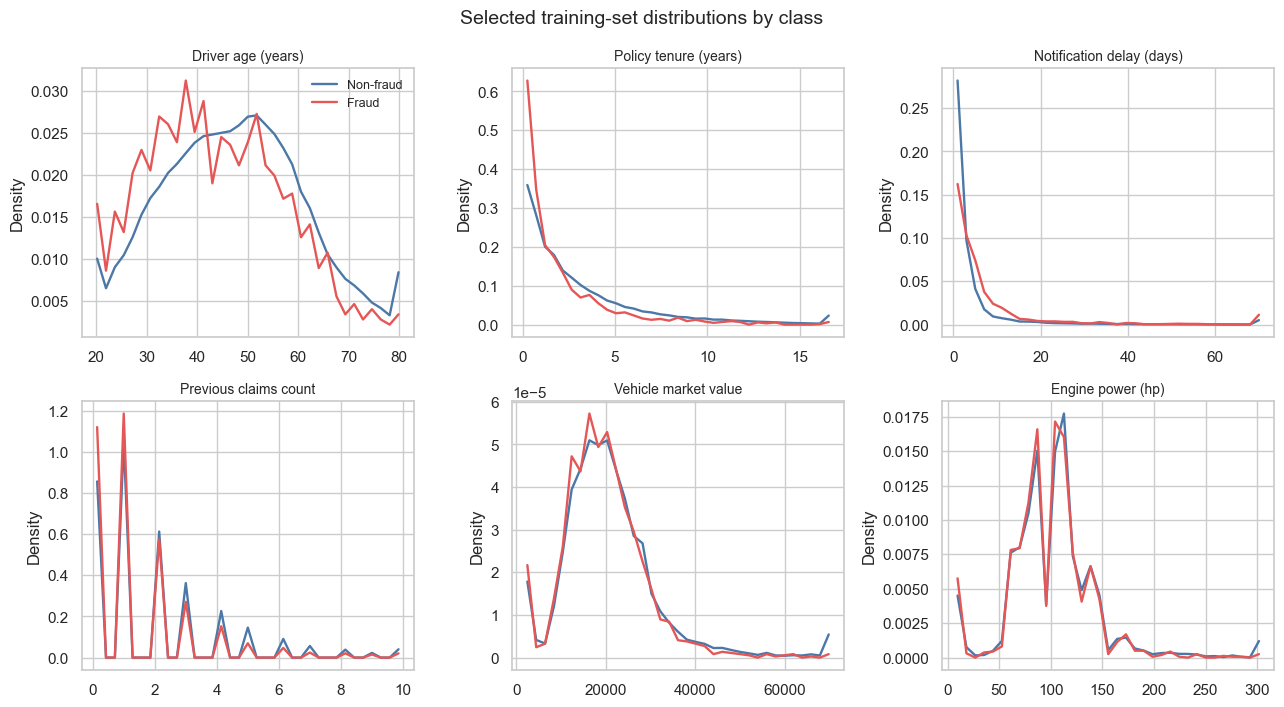

In [8]:
selected_plots = [
    ("edad_conductor1", "Driver age (years)"),
    ("antiguedad_poliza", "Policy tenure (years)"),
    ("dias_notificacion", "Notification delay (days)"),
    ("actasvariacion", "Previous claims count"),
    ("valorvehiculomercado", "Vehicle market value"),
    ("potencia", "Engine power (hp)"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
for ax, (variable, title) in zip(axes.flat, selected_plots):
    values = displayed_values(train, variable)
    lower, upper = values.quantile([0.01, 0.99])
    bins = np.linspace(lower, upper, 36)
    for label, color, class_name in [
        (0, "#4C78A8", "Non-fraud"),
        (1, "#E45756", "Fraud"),
    ]:
        class_values = values[target.eq(label)].clip(lower, upper)
        histogram, edges = np.histogram(class_values, bins=bins, density=True)
        centres = (edges[:-1] + edges[1:]) / 2
        ax.plot(centres, histogram, color=color, linewidth=1.7, label=class_name)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Density")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Selected training-set distributions by class", fontsize=14)
plt.tight_layout()
plt.show()

Fraud cases involve younger drivers: mean age is **43.72 years**, compared with **47.32 years** for non-fraud cases. Fraud cases also have shorter policy tenure: **2.19 years on average** versus **3.28 years**. Notification delay is longer among fraud cases: the median is **4 days**, compared with **2 days**, and the mean is **11.30 days** versus **5.89 days**.


## 6. Categorical Variables

Summarise cardinality, dominant levels, category frequencies, and corrected Cramer's V.


In [9]:
# ---------------------------------------------------------------------
# 6. Categorical descriptions and associations
# ---------------------------------------------------------------------

def corrected_cramers_v(feature, target):
    table = pd.crosstab(feature.astype("string").fillna("<Missing>"), target)
    if table.empty or min(table.shape) < 2:
        return 0.0
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    expected = (
        observed.sum(axis=1, keepdims=True)
        @ observed.sum(axis=0, keepdims=True)
        / n
    )
    valid = expected > 0
    chi_squared = np.sum(((observed - expected) ** 2)[valid] / expected[valid])
    phi_squared = chi_squared / n
    rows, columns = observed.shape
    correction = ((columns - 1) * (rows - 1)) / max(n - 1, 1)
    phi_corrected = max(0.0, phi_squared - correction)
    rows_corrected = rows - ((rows - 1) ** 2) / max(n - 1, 1)
    columns_corrected = columns - ((columns - 1) ** 2) / max(n - 1, 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)
    return math.sqrt(phi_corrected / denominator) if denominator > 0 else 0.0


categorical_rows = []
frequency_rows = []

for variable in categorical_features:
    values = train[variable].astype("string").fillna("<Missing>")
    counts = values.value_counts()
    categorical_rows.append(
        {
            "variable": variable,
            "english_name": english_name(variable),
            "description": descriptions.get(variable, ""),
            "levels": len(counts),
            "most_common_level": counts.index[0],
            "most_common_share": counts.iloc[0] / len(values) * 100,
            "Corrected Cramer's V": corrected_cramers_v(values, target),
        }
    )
    if len(counts) <= 30:
        grouped = (
            pd.DataFrame({"level": values, "target": target})
            .groupby("level")["target"]
            .agg(["count", "sum", "mean"])
            .reset_index()
        )
        grouped["variable"] = variable
        frequency_rows.append(grouped)

categorical_summary = pd.DataFrame(categorical_rows)
categorical_frequencies = pd.concat(frequency_rows, ignore_index=True)
categorical_association = categorical_summary.sort_values(
    "Corrected Cramer's V", ascending=False
)

friendly_names = {
    "garantia_agrupada": "Grouped coverage",
    "scoring": "Risk scoring group",
    "canalnombre": "Sales channel",
    "formapago_agrupado": "Grouped payment method",
    "sexo": "Sex",
    "flota": "Fleet indicator",
}

key_categorical = categorical_summary[
    categorical_summary["variable"].isin(friendly_names)
].copy()
key_categorical["English name"] = key_categorical["variable"].map(friendly_names)
key_categorical["Original variable"] = key_categorical["variable"]
key_categorical = key_categorical[
    ["English name", "Original variable", "levels", "most_common_level", "most_common_share"]
].rename(
    columns={
        "levels": "Levels",
        "most_common_level": "Most common level",
        "most_common_share": "Most common share (%)",
    }
)

display(
    styled_table(
        key_categorical,
        percent_columns=["Most common share (%)"],
        integer_columns=["Levels"],
    )
)

,English name,Original variable,Levels,Most common level,Most common share (%)
8,Risk scoring group,scoring,6,Grupo PROYECTA,50.009%
9,Sales channel,canalnombre,5,AGTES.EXCLUSIVOS,46.876%
20,Fleet indicator,flota,2,0,97.978%
25,Sex,sexo,4,m,58.966%
27,Grouped coverage,garantia_agrupada,10,ASISTENCIA,50.711%
28,Grouped payment method,formapago_agrupado,2,DOMICILIADO,54.674%


The dominant grouped coverage is **ASISTENCIA**, representing **225,195 observations (50.71%)**. The largest risk-scoring group is **Grupo PROYECTA**, with **222,075 observations (50.01%)**. Grouped payment method is relatively balanced: **DOMICILIADO accounts for 54.67%** and **EFECTIVO for 45.33%**. Category values remain in their original Spanish form.


### Fraud rates for selected categories

Plot category-specific fraud rates with category sample sizes and the overall training fraud rate.


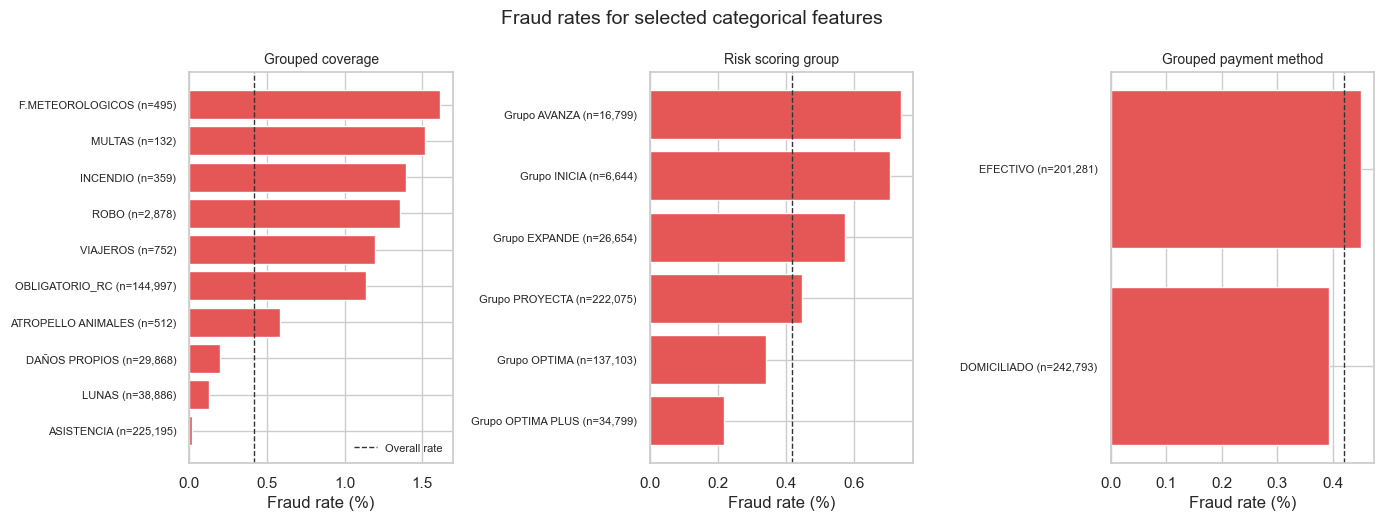

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5.3))
plot_variables = [
    ("garantia_agrupada", "Grouped coverage"),
    ("scoring", "Risk scoring group"),
    ("formapago_agrupado", "Grouped payment method"),
]

for ax, (variable, title) in zip(axes, plot_variables):
    subset = categorical_frequencies[
        categorical_frequencies["variable"].eq(variable)
    ].nlargest(10, "count")
    subset = subset[subset["count"].ge(100)].sort_values("mean")
    labels = [
        f"{level} (n={count:,})"
        for level, count in zip(subset["level"], subset["count"])
    ]
    ax.barh(labels, subset["mean"] * 100, color="#E45756")
    ax.axvline(
        fraud_rate,
        color="#333333",
        linestyle="--",
        linewidth=1,
        label="Overall rate",
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Fraud rate (%)")
    ax.tick_params(axis="y", labelsize=8)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Fraud rates for selected categorical features", fontsize=14)
plt.tight_layout()
plt.show()

Grouped coverage shows the largest visible rate differences. **F.METEOROLOGICOS has a 1.62% fraud rate (8 of 495)** and **ROBO has 1.36% (39 of 2,878)**, while **ASISTENCIA has 0.018% (40 of 225,195)**. The small weather-related category produces a less stable estimate than the major coverage groups. For risk scoring, **Grupo AVANZA has the highest rate at 0.738%**, compared with **0.218% for Grupo OPTIMA PLUS**. Payment-method differences are small: **0.451% for EFECTIVO** and **0.392% for DOMICILIADO**.


### Strongest categorical associations

Show the largest corrected Cramer's V values, with variable descriptions.


In [11]:
display(
    styled_table(
        categorical_association.head(8)[
            ["english_name", "variable", "levels", "Corrected Cramer's V"]
        ].rename(
            columns={
                "english_name": "English name",
                "variable": "Original variable",
                "levels": "Levels",
            }
        ),
        decimal_columns=["Corrected Cramer's V"],
        integer_columns=["Levels"],
    )
)

,English name,Original variable,Levels,Corrected Cramer's V
0,region_code o district_code,comarcaid,77,0.092
1,coverage_type,garantia,26,0.080
27,Grouped coverage,garantia_agrupada,10,0.080
18,policyholder_customer_tier,tomadornivel,11,0.050
12,policyholder_postal_code,tomadorcodigopostal,"2,569",0.049
16,policyholder_nationality_id,tomadornacionalidadid,"2,421",0.048
13,policyholder_municipality_id,tomadormunicipioid,"1,816",0.035
15,policyholder_district_id,tomadorcomarcaid,76,0.034


The strongest categorical association is **region/district code (`comarcaid`) with corrected Cramer's V = 0.092**. Grouped coverage and detailed coverage both have values around **0.080**. These are weak associations; no categorical variable provides strong stand-alone separation between fraud and non-fraud.


## 7. Fraud and Non-Fraud Comparison

Compare the largest numeric differences between the two classes. Positive standardized differences mean higher values among fraud cases; negative values mean lower values among fraud cases.


In [12]:
display(
    styled_table(
        numeric_comparison.head(8).drop(columns="absolute_difference"),
        decimal_columns=["Std. difference", "Correlation"],
    )
)
# The table is followed by a specific interpretation in the next Markdown cell.

,English name,Original variable,Direction,Std. difference,Correlation
40,"Percentage of income from other benefits (disability, dependency...)",ine_008,Higher in fraud,0.378,0.024
73,Percentage of people with unmarried marital status,ine_041,Higher in fraud,0.338,0.022
43,Average household size,ine_011,Higher in fraud,0.337,0.022
70,Percentage of population retired due to retirement over population 16 and over=Pension...,ine_038,Lower in fraud,-0.326,-0.021
58,Percentage of persons under 16 years of age,ine_026,Higher in fraud,0.313,0.020
57,Average age (census),ine_025,Lower in fraud,-0.309,-0.020
47,Percentage of population under 18 years of age (census),ine_015,Higher in fraud,0.301,0.019
112,Policy tenure,antiguedad_poliza,Lower in fraud,-0.299,-0.019


The largest standardized numeric difference is for **income from other benefits (`ine_008`) at 0.378**. Fraud cases have lower policy tenure (**standardized difference -0.299**) and lower driver age (**-0.258**). Despite these group differences, all point-biserial correlations are small in absolute terms, with the largest around **0.024**, so none of these variables should be used as an individual fraud rule.


## 8. Correlation Analysis

Inspect redundancy among numeric variables, particularly related area-level indicators.


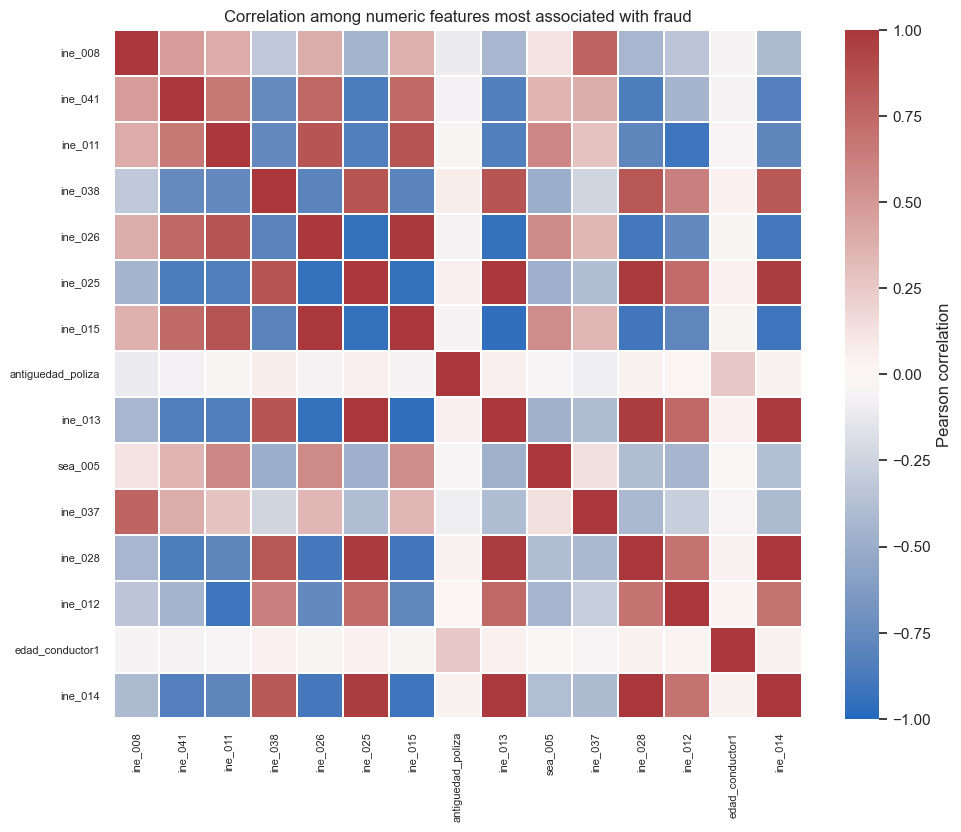

In [13]:
# ---------------------------------------------------------------------
# 7. Correlation and train/test feature distribution
# ---------------------------------------------------------------------

numeric_frame = pd.DataFrame(
    {variable: displayed_values(train, variable) for variable in numeric_features}
)
correlation = numeric_frame.corr(method="pearson")
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
high_correlation_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .query("abs(correlation) >= 0.80")
    .sort_values("correlation", key=lambda series: series.abs(), ascending=False)
)

selected = numeric_comparison.head(15)["Original variable"].tolist()
fig, ax = plt.subplots(figsize=(10, 8.3))
sns.heatmap(
    correlation.loc[selected, selected],
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlation among numeric features most associated with fraud")
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# See the specific interpretation below.

There are **186 numeric feature pairs with |r| >= 0.80**. Several are exact or near-exact complements or duplicates, including women versus men (`ine_023` and `ine_024`, **r = -1.000**), detached/semi-detached houses versus apartments (`rep_002` and `rep_003`, **r = -1.000**), and principal dwellings versus total households (`ine_047` and `ine_052`, **r = 1.000**). These variables describe overlapping area characteristics and should not be interpreted as independent effects.


## 9. Train and Test Comparison

Compare train and test features without loading or using the test target.


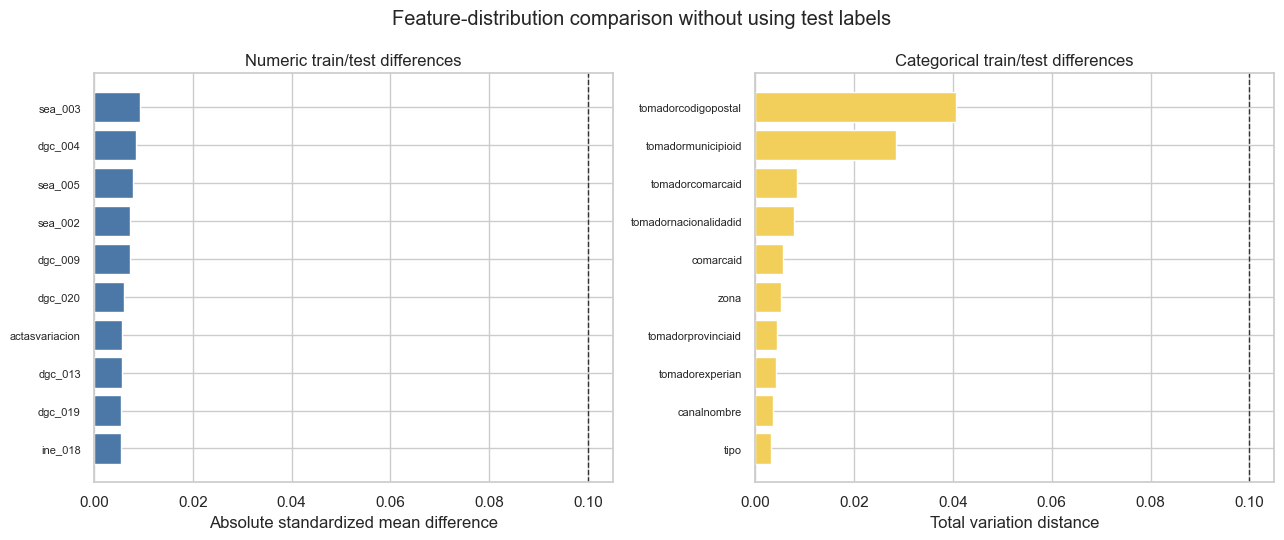

In [14]:
numeric_drift_rows = []
for variable in numeric_features:
    train_values = displayed_values(train, variable)
    test_values = displayed_values(test_features, variable)
    pooled_sd = math.sqrt(
        max((float(train_values.var()) + float(test_values.var())) / 2, 0)
    )
    difference = (
        (test_values.mean() - train_values.mean()) / pooled_sd
        if pooled_sd > 0
        else 0
    )
    numeric_drift_rows.append(
        {
            "variable": variable,
            "difference": abs(difference),
        }
    )

categorical_drift_rows = []
for variable in categorical_features:
    train_distribution = (
        train[variable].astype("string").fillna("<Missing>").value_counts(normalize=True)
    )
    test_distribution = (
        test_features[variable]
        .astype("string")
        .fillna("<Missing>")
        .value_counts(normalize=True)
    )
    levels = train_distribution.index.union(test_distribution.index)
    distance = 0.5 * np.abs(
        train_distribution.reindex(levels, fill_value=0)
        - test_distribution.reindex(levels, fill_value=0)
    ).sum()
    categorical_drift_rows.append(
        {
            "variable": variable,
            "distance": distance,
        }
    )

numeric_drift = pd.DataFrame(numeric_drift_rows).sort_values(
    "difference", ascending=False
)
categorical_drift = pd.DataFrame(categorical_drift_rows).sort_values(
    "distance", ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
numeric_plot = numeric_drift.head(10).sort_values("difference")
categorical_plot = categorical_drift.head(10).sort_values("distance")

axes[0].barh(numeric_plot["variable"], numeric_plot["difference"], color="#4C78A8")
axes[0].axvline(0.1, color="#333333", linestyle="--", linewidth=1)
axes[0].set_title("Numeric train/test differences")
axes[0].set_xlabel("Absolute standardized mean difference")
axes[0].tick_params(axis="y", labelsize=8)

axes[1].barh(
    categorical_plot["variable"],
    categorical_plot["distance"],
    color="#F2CF5B",
)
axes[1].axvline(0.1, color="#333333", linestyle="--", linewidth=1)
axes[1].set_title("Categorical train/test differences")
axes[1].set_xlabel("Total variation distance")
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle("Feature-distribution comparison without using test labels")
plt.tight_layout()
plt.show()

# See the specific interpretation below.

The largest numeric standardized difference between train and test is **0.009**, and the largest categorical total variation distance is **0.041**. No feature exceeds the **0.10** review threshold. The grouped split therefore preserves comparable feature distributions without using the test target.


## 10. Conclusions

1. The training set contains **444,074 observations and 1,860 fraud cases**, giving a fraud prevalence of **0.4188%** and a non-fraud-to-fraud ratio of approximately **238:1**.

2. The data contain no missing values, but several fields require documentation: **73.38%** of maximum-authorised-weight values are zero, **9.65%** of door counts are non-integer, **331** notification delays exceed one year, and **6** policy-tenure values are negative.

3. The two time variables are stored as fractions of a year despite being described as days. Policy tenure is presented in years, while notification delay is converted to days by multiplying by **365.25**.

4. Fraud cases involve younger drivers (**43.72 vs 47.32 years**), shorter policy tenure (**2.19 vs 3.28 years**), and longer notification delays (**median 4 vs 2 days**).

5. Coverage shows meaningful rate variation, but small categories produce unstable estimates. The strongest categorical association is weak (**corrected Cramer's V = 0.092**), and the largest numeric correlation with fraud is only about **0.024**.

6. Area-level variables contain substantial redundancy, with **186 numeric pairs** having **|r| >= 0.80**.

7. Train and test feature distributions are comparable: the largest numeric difference is **0.009** and the largest categorical distance is **0.041**, both below the **0.10** review threshold.
